In [1]:
import analysis_functions
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [2]:
# Make output folder
output_dir = os.path.join('..','plots','behavioural_pilot')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Preparation
experiment_output_path = '/Users/kenneth.van.der.zee/Documents/phd_1_task/experiment_output'

In [4]:
unique_subject_ids = [1, 2, 3]  #list(range(1, 46))
unique_sessions = [1]

recent_results = analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)

In [5]:
print(recent_results)

['/Users/kenneth.van.der.zee/Documents/phd_1_task/experiment_output/experiment_output_sub-001_session-01_2024-04-10_13:37:11.csv', '/Users/kenneth.van.der.zee/Documents/phd_1_task/experiment_output/experiment_output_sub-002_session-01_2024-04-10_15:48:45.csv', '/Users/kenneth.van.der.zee/Documents/phd_1_task/experiment_output/experiment_output_sub-003_session-01_2024-04-12_15:40:55.csv']


In [6]:
combined_results_dataframe = analysis_functions.combine_result_files(recent_results)
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.712749e+09     down                Even   
1         1        1.712749e+09       up                Even   
2         2        1.712749e+09       up                Even   
3         3        1.712749e+09       up                Even   
4         4        1.712749e+09      NaN                Even   
...     ...                 ...      ...                 ...   
1435    475        1.712933e+09       up                True   
1436    476        1.712933e+09     down               False   
1437    477        1.712933e+09     down                True   
1438    478        1.712933e+09       up                True   
1439    479        1.712933e+09       up                True   

      subjectively_correct  response_time      RT_s  stimuli_type  iti  \
0                    False   1.712749e+09  0.947126             3  3.5   
1                    False   1.712749e+09  0.889028             2  3.5   
2        

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [7]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional column for congruency

In [8]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

      stimuli_type  probability_condition   congruency
0                3                   50.0    undefined
1                2                   50.0    undefined
2                2                   50.0    undefined
3                3                   50.0    undefined
4                4                   50.0    undefined
...            ...                    ...          ...
1435             4                   80.0    congruent
1436             1                   20.0    congruent
1437             3                   80.0    congruent
1438             1                   20.0    congruent
1439             2                   80.0  incongruent

[1440 rows x 3 columns]


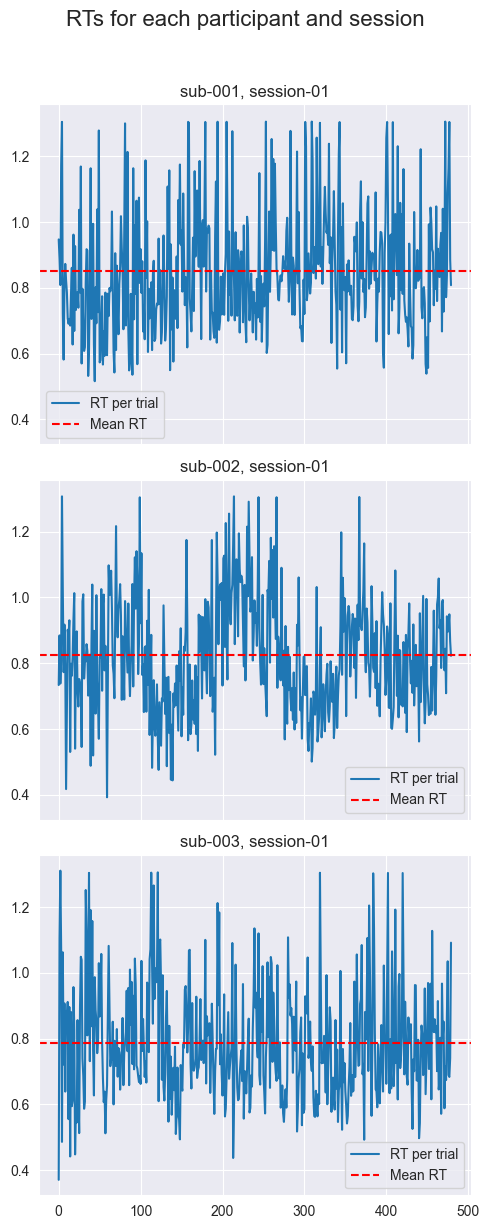

In [9]:
# Subplots for RT
## Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), sharex=True, sharey=True)
fig.suptitle('RTs for each participant and session', fontsize=16, y=1.02)

if n_rows == 1 or n_cols == 1:
    axes = np.array(axes).reshape(n_rows, n_cols)

## Loop through each combination of 'session' and 'subject_id' and create a plot
for i, session in enumerate(unique_sessions):
    for j, subject_id in enumerate(unique_subject_ids):
        ax_index = j * len(unique_sessions) + i
        ax = axes[j, i]

        ## Filter the dataframe for the current session and subject_id
        subset = combined_results_dataframe[(combined_results_dataframe['session'] == session) & (combined_results_dataframe['subject_id'] == subject_id)]

        ## Plot
        ax.plot(subset['RT_s'].values, label=f'RT per trial')
        ax.axhline(subset['RT_s'].mean(), color='r', linestyle='--', label='Mean RT')
        ax.set_title(f'{subject_id}, {session}')
        ax.legend()

## Adjust layout
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'RT_for_each_participant_and_session.pdf'))
plt.show()

Analyse response time for happy-angry approach-avoid, check manuscript


In [10]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

# Statistics
Start by checking if the objectively correct answers significantly differ from chance

In [11]:
# Filter out trials with 50% reward probability and without responses
stats_dataframe = combined_results_dataframe.drop(combined_results_dataframe[(combined_results_dataframe.probability_condition == 50) | (combined_results_dataframe.objectively_correct == 'Late')].index, inplace=False)
# Calculate the total number of successes and the total number of trials
total_successes = stats_dataframe['objectively_correct_boolean'].sum()
total_trials = len(stats_dataframe)

# Calculate expected successes and failures if each trial has a 50% chance of success
expected_successes = total_trials * 0.5
expected_failures = total_trials * 0.5

# Perform the chi-square goodness of fit test
chi2_stat, p_value = chisquare([total_successes, total_trials - total_successes],
                               f_exp=[expected_successes, expected_failures])

print(chi2_stat, p_value)

16.625925925925927 4.55244577996673e-05


In [12]:
# Multiply the boolean response by 100 to get percentages, can only do this after the stats
combined_results_dataframe['objectively_correct_boolean'] *= 100

# Objectively correct answer binned after every switch

In [13]:
# Create a dataframe with objectively correct responses up to 12 trials after switch
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0

objectively_correct_answers_per_switch_block = pd.DataFrame()

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]
        
        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        
        # Filter out trials with 50% reward probability and without responses
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.drop(combined_results_grouped_dataframe[(combined_results_grouped_dataframe.probability_condition == 50) | (combined_results_grouped_dataframe.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.reset_index()
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()
        print(f'{index_stimuli}, {index_subject_id}, {switches_reward}')
        
        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = dataframe_containing_groups_filtered.iloc[values:values+13]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7, 10: 8, 11: 9, 12: 10, 13: 11, 14: 12})

3, sub-001, [0, 12, 30, 45, 60, 78]
3, sub-002, [0, 18, 30, 45, 60, 78]
3, sub-003, [0, 12, 30, 42, 60, 75]
2, sub-001, [0, 18, 30, 42, 60, 75]
2, sub-002, [0, 18, 30, 48, 60, 75]
2, sub-003, [0, 18, 30, 45, 60, 72]
4, sub-001, [0, 12, 30, 45, 60, 78]
4, sub-002, [0, 12, 30, 45, 60, 78]
4, sub-003, [0, 18, 30, 45, 60, 78]
1, sub-001, [0, 15, 30, 48, 60, 72]
1, sub-002, [0, 15, 30, 42, 60, 72]
1, sub-003, [0, 15, 30, 42, 60, 78]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_42102/1628670542.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_42102/1628670542.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/b

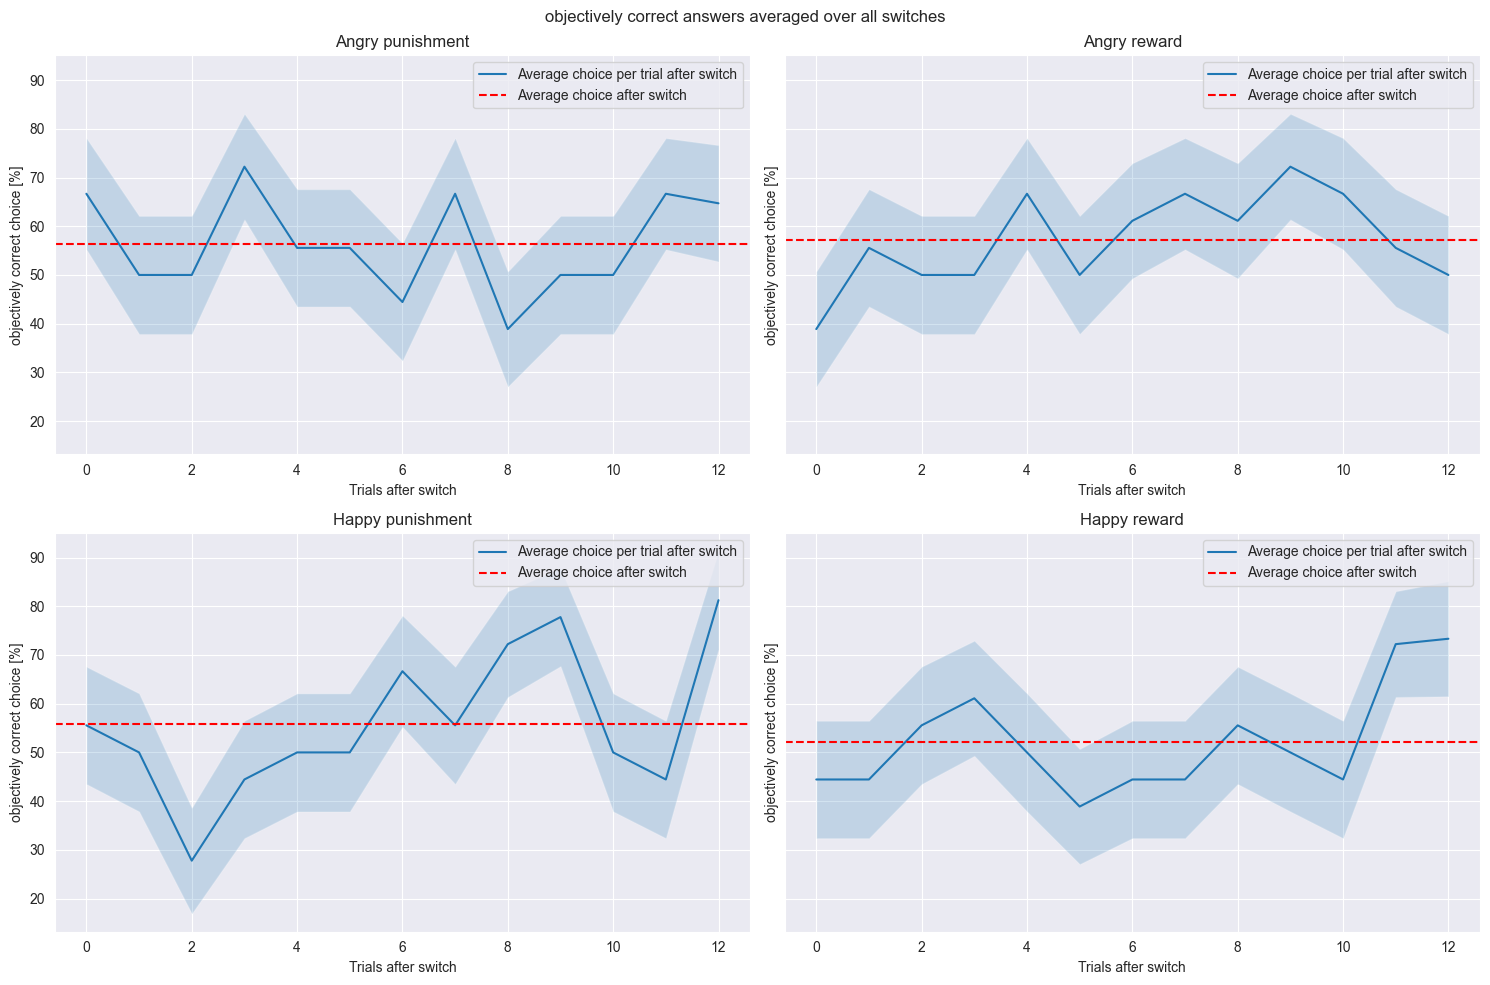

In [14]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('objectively correct answers averaged over all switches')

stimuli_types_list = ['Angry punishment','Angry reward','Happy punishment','Happy reward']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = np.arange(len(means.columns))
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch')
    axs[i].set_ylabel('objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_switches.pdf'))
plt.show()

## objectively correct answers without binning
Now we'll look at the objectively correct answers in a sequential manner, so without binning them based on switches in reward contingencies.
Plot probability of correct response on Y-axis to trials on X-axis

In [15]:
# Take the mean from all 12 trials after each switch
trials_after_switch_to_plot = list(range(0,13))
intermediate_dataframe = objectively_correct_answers_per_switch_block
intermediate_dataframe['switch_number'] = intermediate_dataframe.groupby(['subject_id','stimuli_type']).cumcount()
print(intermediate_dataframe)

# Preparation for loop
unique_switches = intermediate_dataframe['switch_number'].unique()
column_names = ['stimuli_type', 'switch'] + trials_after_switch_to_plot
objectively_correct_answers_averaged_per_switch_block = pd.DataFrame(columns = column_names)

# Loop through each stimulus and switch type
for index_stimuli, value_stimuli in enumerate(unique_stimuli_types):
    for index_switch, value_switch in enumerate(unique_switches):
        filtered_dataframe = intermediate_dataframe[(intermediate_dataframe['stimuli_type'] == value_stimuli) & (intermediate_dataframe['switch_number'] == value_switch)]
        list_with_averages = [value_stimuli, value_switch] + (filtered_dataframe[trials_after_switch_to_plot].mean()).to_list()
        objectively_correct_answers_averaged_per_switch_block.loc[len(objectively_correct_answers_averaged_per_switch_block)] = list_with_averages

objectively_correct_answers_averaged_per_switch_block['mean'] = objectively_correct_answers_averaged_per_switch_block[trials_after_switch_to_plot].mean(axis=1)

   subject_id  stimuli_type    0    1    2    3    4    5    6    7    8    9  \
0     sub-001             3  100    0    0  100  100  100    0  100  100  100   
1     sub-001             3  100    0    0  100    0  100  100  100    0    0   
2     sub-001             3    0  100    0  100    0  100  100    0  100  100   
3     sub-001             3  100    0    0    0  100    0  100    0  100  100   
4     sub-001             3    0  100    0  100  100    0    0  100  100  100   
..        ...           ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
67    sub-003             1    0    0    0  100    0    0    0  100  100  100   
68    sub-003             1  100  100    0  100  100    0  100    0    0  100   
69    sub-003             1  100  100    0    0  100  100  100  100    0    0   
70    sub-003             1  100  100  100  100    0    0    0  100  100    0   
71    sub-003             1    0  100  100  100  100  100  100  100    0  100   

     10   11     12  switch

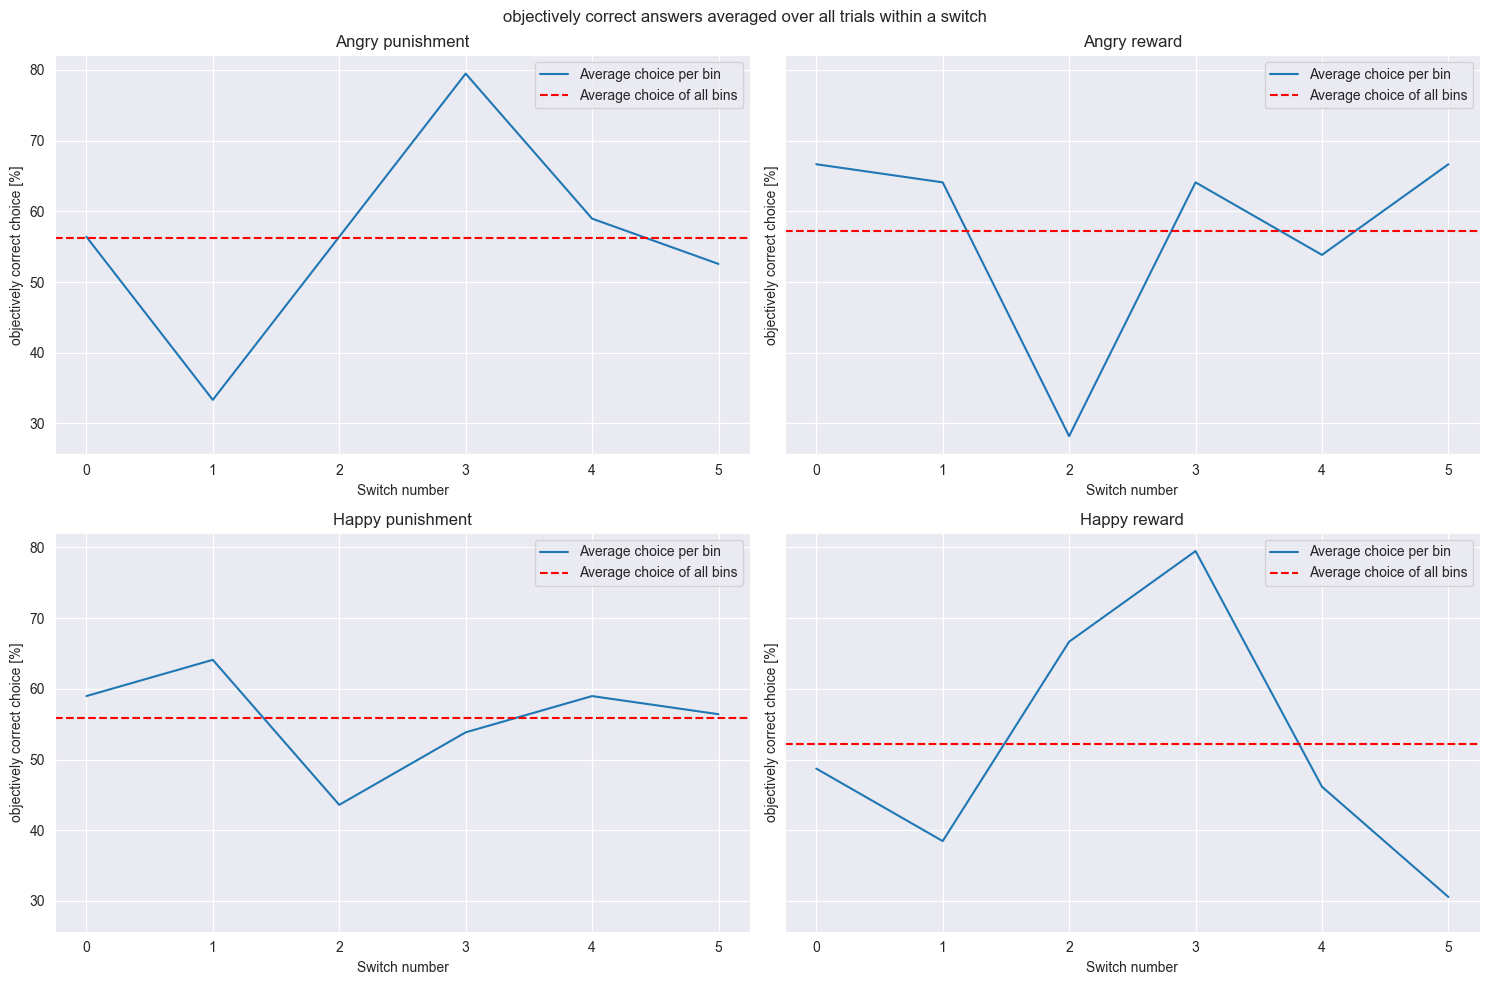

In [16]:
# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('objectively correct answers averaged over all trials within a switch')

for index_stimuli, value_stimuli in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    filtered_dataframe = objectively_correct_answers_averaged_per_switch_block[objectively_correct_answers_averaged_per_switch_block['stimuli_type'] == value_stimuli]

    axs[index_stimuli].plot(unique_switches, filtered_dataframe['mean'], label='Average choice per bin')
    axs[index_stimuli].axhline((average_choice_after_switch_total[index_stimuli]), color='r', linestyle='--', label='Average choice of all bins')
    axs[index_stimuli].set_title(stimuli_types_list[index_stimuli])
    axs[index_stimuli].set_xlabel('Switch number')
    axs[index_stimuli].set_ylabel('objectively correct choice [%]')
    axs[index_stimuli].legend()
    axs[index_stimuli].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_trials_within_switch.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 12 trials before the switch and ending 4 after.

In [17]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-12, 5))

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values-12:values+5]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: -12, 3: -11, 4: -10, 5: -9, 6: -8, 7: -7, 8: -6, 9: -5, 10: -4, 11: -3, 12: -2, 13: -1, 14: 0, 15: 1, 16: 2, 17: 3, 18: 4})

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_42102/3754995200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_42102/3754995200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/b

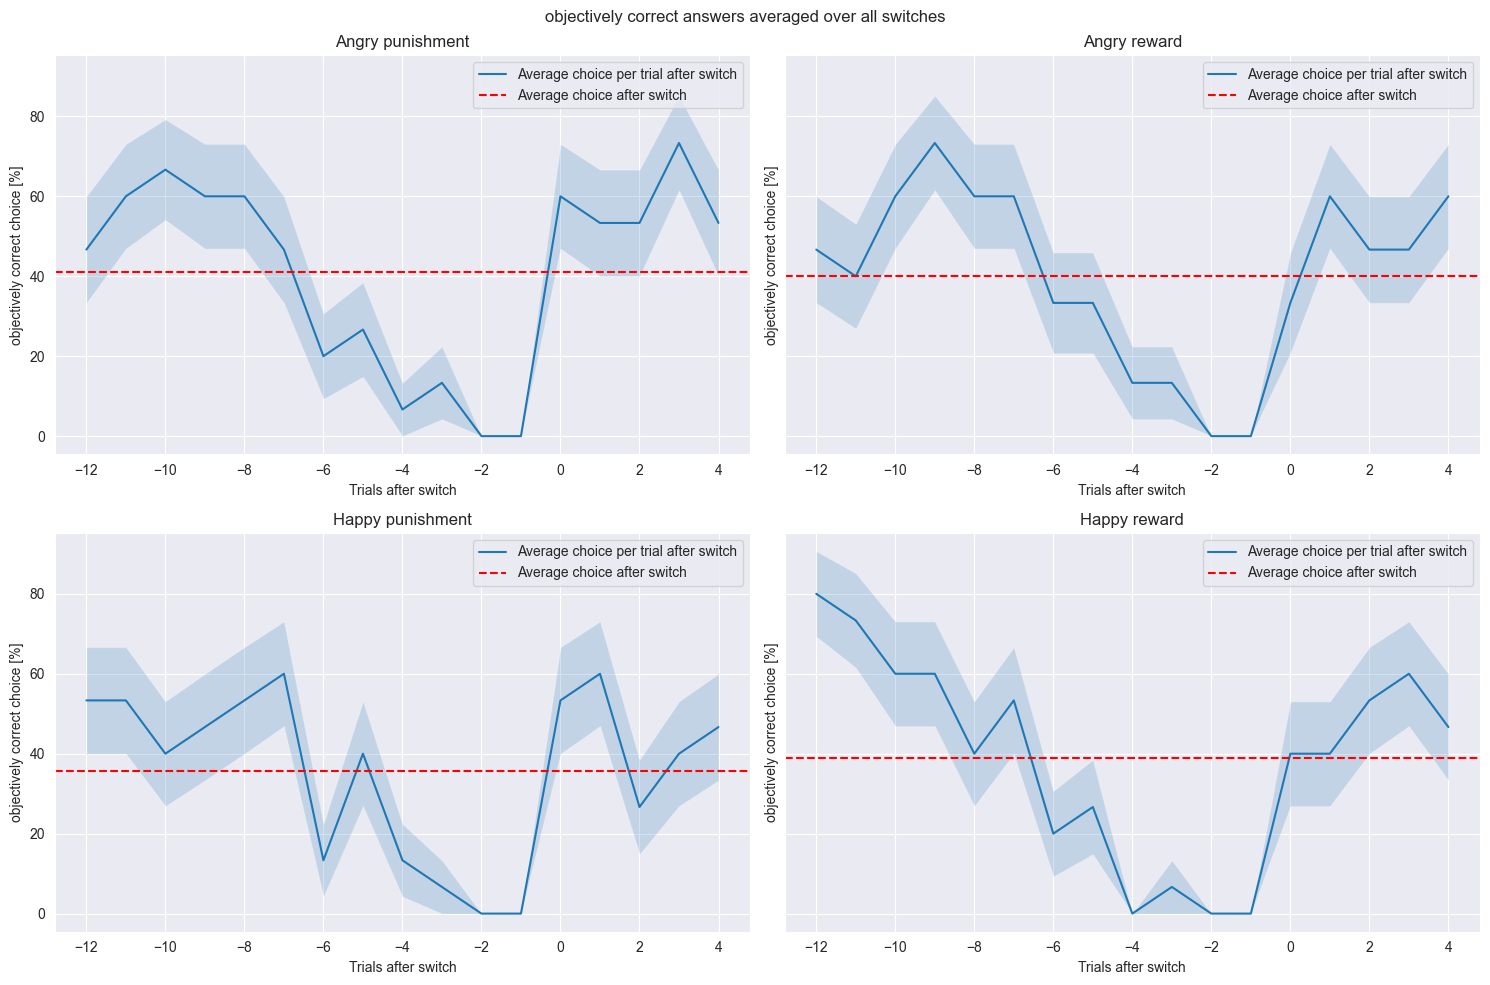

In [18]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('objectively correct answers averaged over all switches')

stimuli_types_list = ['Angry punishment','Angry reward','Happy punishment','Happy reward']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch')
    axs[i].set_ylabel('objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_switches.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 4 trials before the switch and ending 12 after.

In [19]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-4, 13))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: -4, 3: -3, 4: -2, 5: -1, 6: 0, 7: 1, 8: 2, 9: 3, 10: 4, 11: 5, 12: 6, 13: 7, 14: 8, 15: 9, 16: 10, 17: 11, 18: 12}

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values+min(plot_range):values+max(plot_range)+1]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns=mapping)
print(objectively_correct_answers_per_switch_block)

   subject_id  stimuli_type     -4     -3   -2   -1      0      1      2  \
0     sub-001             3    0.0    0.0  0.0  0.0  100.0    0.0    0.0   
1     sub-001             3    0.0    0.0  0.0  0.0  100.0    0.0    0.0   
2     sub-001             3  100.0  100.0  0.0  0.0    0.0  100.0    0.0   
3     sub-001             3    0.0    0.0  0.0  0.0  100.0    0.0    0.0   
4     sub-001             3    0.0    0.0  0.0  0.0    0.0  100.0    0.0   
..        ...           ...    ...    ...  ...  ...    ...    ...    ...   
67    sub-003             1    0.0    0.0  0.0  0.0    0.0    0.0    0.0   
68    sub-003             1    0.0    0.0  0.0  0.0  100.0  100.0    0.0   
69    sub-003             1    0.0    0.0  0.0  0.0  100.0  100.0    0.0   
70    sub-003             1  100.0  100.0  0.0  0.0  100.0  100.0  100.0   
71    sub-003             1    0.0    0.0  0.0  0.0    0.0  100.0  100.0   

        3      4      5      6      7      8      9     10     11     12  
0   100.0  1

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_42102/2712700415.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_42102/2712700415.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/b

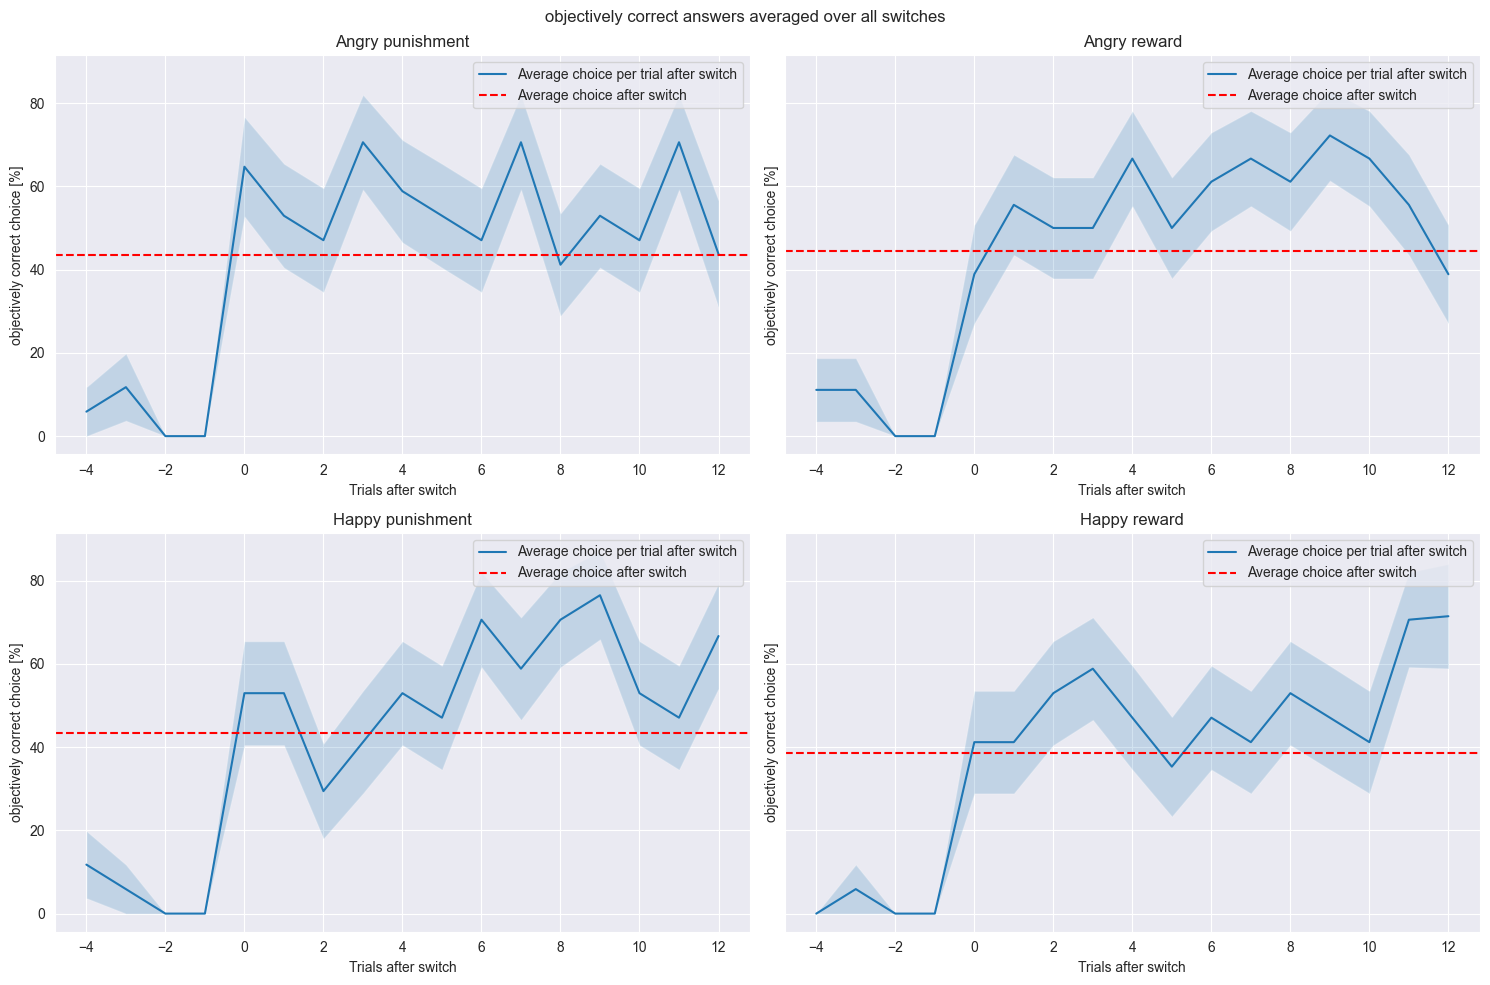

In [20]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('objectively correct answers averaged over all switches')

stimuli_types_list = ['Angry punishment','Angry reward','Happy punishment','Happy reward']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch')
    axs[i].set_ylabel('objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_switches.pdf'))
plt.show()

# Subplots for incongruent and congruent switches

In [21]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(0, 13))
mapping = {0: 'stimuli_type', 1: 'subject_id', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10, 14: 11, 15: 12}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                 unique_subject_ids,
                                                                 unique_stimuli_types,
                                                                 'congruency',
                                                                 plot_range,
                                                                 mapping)
print(all_switches_dataframe)

   stimuli_type  subject_id   congruency    0    1    2    3    4    5    6  \
0       sub-001           3  incongruent  100    0    0  100  100  100    0   
1       sub-001           3  incongruent  100    0    0  100    0  100  100   
2       sub-001           3  incongruent  100    0    0    0  100    0  100   
3       sub-001           3    congruent    0  100    0  100    0  100  100   
4       sub-001           3    congruent    0  100    0  100  100    0    0   
..          ...         ...          ...  ...  ...  ...  ...  ...  ...  ...   
67      sub-003           1    congruent  100  100  100  100    0    0    0   
68      sub-003           1    congruent    0  100  100  100  100  100  100   
69      sub-003           1  incongruent    0    0    0  100    0    0    0   
70      sub-003           1  incongruent  100  100    0  100  100    0  100   
71      sub-003           1  incongruent  100  100    0    0  100  100  100   

      7    8    9   10   11     12  
0   100  100  

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/scripts/analysis_functions.py:260: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/scripts/analysis_functions.py:260: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/sc

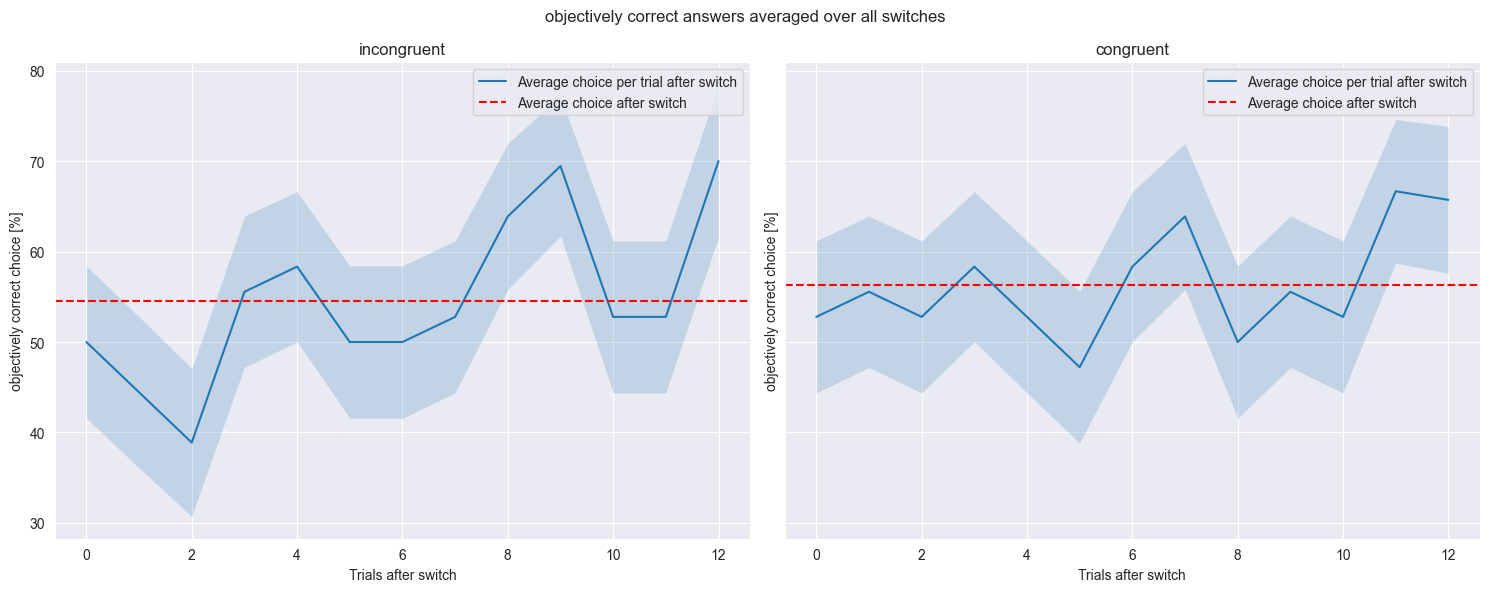

In [22]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('objectively correct answers averaged over all switches')

congruency_list = all_switches_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch')
    axs[i].set_ylabel('objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_per_congruency.pdf'))
plt.show()

# Subplots for reversal and non-reversal switches

In [23]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(0, 13))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'all_reversals', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10, 14: 11, 15: 12}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = analysis_functions.find_switches_in_dataframe_separate_reversals(combined_results_dataframe,
                                                                                          unique_subject_ids,
                                                                                          unique_stimuli_types,
                                                                                          plot_range,
                                                                                          mapping)
print(all_switches_dataframe)

   subject_id  stimuli_type  all_reversals    0    1    2    3    4    5    6  \
0     sub-001             3            1.0  100    0    0  100  100  100    0   
1     sub-001             3            2.0  100    0    0  100    0  100  100   
2     sub-001             3            1.0    0  100    0  100    0  100  100   
3     sub-001             3            1.0  100    0    0    0  100    0  100   
4     sub-001             3            1.0    0  100    0  100  100    0    0   
..        ...           ...            ...  ...  ...  ...  ...  ...  ...  ...   
67    sub-003             1            1.0    0    0    0  100    0    0    0   
68    sub-003             1            2.0  100  100    0  100  100    0  100   
69    sub-003             1            2.0  100  100    0    0  100  100  100   
70    sub-003             1            1.0  100  100  100  100    0    0    0   
71    sub-003             1            2.0    0  100  100  100  100  100  100   

      7    8    9   10   11

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/scripts/analysis_functions.py:314: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/scripts/analysis_functions.py:314: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1

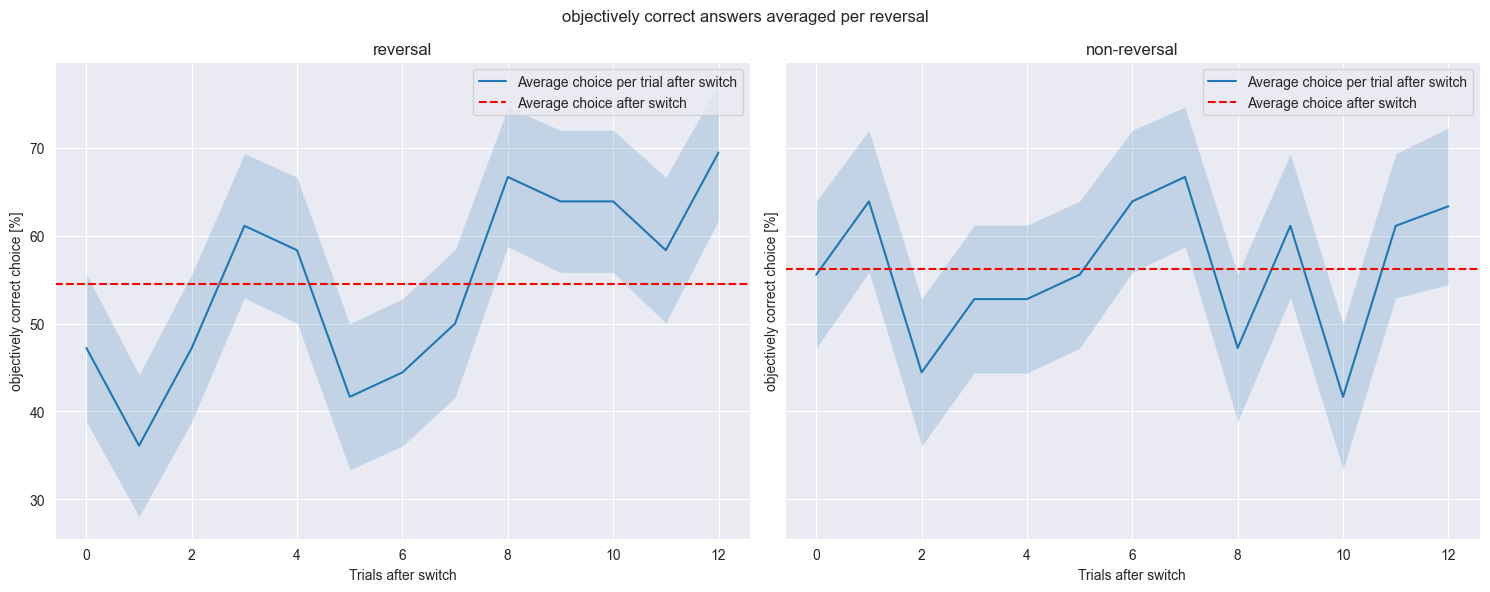

In [24]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('all_reversals')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('all_reversals').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('all_reversals').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False,
                        sharey=True)  # Adjust based on the number of stimuli_types
axs = axs.flatten()  # Flatten to iterate easily

fig.suptitle('objectively correct answers averaged per reversal')

congruency_list = ['reversal','non-reversal']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--',
                   label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch')
    axs[i].set_ylabel('objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_per_reversal.pdf'))
plt.show()